# Comparing hyperparameter optimizers

This notebook is the analysis source for a **12–15 page project report** and a short presentation. It reads a snapshot of completed experiments without changing or stopping the runner. Rerun all cells to refresh that snapshot. Findings are provisional while coverage is incomplete.

**Questions:** Which optimizer performs best at each budget? Does the answer depend on the model or data? How much time does improved performance cost? How stable are the comparisons across seeds?

**Report allocation:** introduction and related work (2–3 pages), data and protocol (3 pages), results (4–5 pages), statistical interpretation and limitations (1–2 pages), conclusion (1 page). Use Figures 1–5 in the main report, select one convergence panel from Figure 6, and move full per-cell tables and additional diagnostics to an appendix. For a presentation, use coverage, performance heatmap, budget gains, runtime, and one convergence panel.

The notebook exports numbered figures, tables, a coverage manifest, and caveats to `figures/final_analysis/`. It does not write experiment results.

In [14]:
from pathlib import Path
import os, sys, json, hashlib, itertools
from collections import Counter
# Set HPO_PROJECT_ROOT to an absolute checkout path when using another machine.
# The local fallback also recovers a kernel whose old working directory vanished.
LOCAL_CHECKOUT = Path("/Users/ecilteodoro/Library/Mobile Documents/com~apple~CloudDocs/UWF/2026-8/MAP6114/project-repo")

def locate_project_root():
    override = os.environ.get('HPO_PROJECT_ROOT')
    if override:
        candidates = [Path(override).expanduser()]
        if not candidates[0].is_absolute():
            raise ValueError('HPO_PROJECT_ROOT must be an absolute path.')
    else:
        candidates = []
        try:
            candidates.append(Path.cwd())
        except FileNotFoundError:
            pass
        previous_root = globals().get('ROOT')
        if previous_root is not None and Path(previous_root).is_absolute():
            candidates.append(Path(previous_root))
        shell_directory = os.environ.get('PWD')
        if shell_directory and Path(shell_directory).is_absolute():
            candidates.append(Path(shell_directory))
        candidates.append(LOCAL_CHECKOUT)
    for candidate in candidates:
        for directory in (candidate, *candidate.parents):
            if (directory / 'configs/experiments.yaml').is_file() and (directory / 'src/hpo_project').is_dir():
                return directory.resolve()
    raise FileNotFoundError('Project checkout not found. Set HPO_PROJECT_ROOT to its absolute path, then rerun this cell.')

ROOT = locate_project_root()
os.chdir(ROOT)  # Restore a valid kernel working directory for later cells.
print(f'Project root: {ROOT}')
OUT = ROOT / 'figures' / 'final_analysis'
OUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(OUT / '.mplconfig'))
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare, studentized_range
from IPython.display import display, Markdown
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 220})
CONFIG = yaml.safe_load((ROOT / 'configs/experiments.yaml').read_text())
OPTIMIZERS = CONFIG['optimizers']
BUDGETS = CONFIG['budgets']
SEEDS = CONFIG['seeds']
CELL = ['dataset', 'condition', 'model']
PAIR = CELL + ['budget', 'seed']
# None selects the largest completed cohort with the current search spaces.
# Set an explicit hash to reproduce a chosen analysis snapshot.
SOURCE_HASH = None
SPACES = yaml.safe_load((ROOT / 'configs/search_spaces.yaml').read_text())
def export_table(frame, name):
    frame.to_csv(OUT / f'{name}.csv', index=False)
    display(frame)
def export_figure(fig, name):
    fig.savefig(OUT / f'{name}.png', bbox_inches='tight')
    fig.savefig(OUT / f'{name}.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)

Project root: /Users/ecilteodoro/Library/Mobile Documents/com~apple~CloudDocs/UWF/2026-8/MAP6114/project-repo


## 1. Snapshot, provenance, and coverage

We exclude pilots, incomplete files, unplanned combinations, and results whose search space or CV settings differ from the current protocol. We then select **one source-code cohort**; we never pool results across code versions. The default selects the largest eligible cohort, not necessarily the newest. Review its provenance before using the report. Exact source and package metadata remain in the run files.

Budget-25 and budget-100 summaries from random/Bayesian search are separate observations derived from one search history, not two independent runs. Each optimizer comparison uses matching dataset, condition, model, budget, and seed. Missing optimizers are excluded from comparative panels. Full-seed coverage is required for inferential testing.

Selected source: 5f5b6e60da15ed1c5be07110bdfa0c1147b0502ee46a819fca83e9e5d938fdb4; completed runs: 300; paired seed/budget comparisons: 99


,source_hash,eligible_run_files,selected
0,5f5b6e60da15ed1c5be07110bdfa0c1147b0502ee46a81...,300,True


Excluded files: {'incompatible protocol': 269, 'interrupted': 1, 'running': 1}


,dataset,condition,model,budget,complete_optimizer_seed_scores,paired_seeds,expected_seeds
0,white_wine,base,elastic_net,25,4,1,10
1,white_wine,base,elastic_net,100,4,1,10
2,white_wine,base,svm,25,0,0,10
3,white_wine,base,svm,100,0,0,10
4,white_wine,base,lightgbm,25,4,1,10
...,...,...,...,...,...,...,...
97,synthetic_imbalanced,base,elastic_net,100,4,1,10
98,synthetic_imbalanced,base,svm,25,4,1,10
99,synthetic_imbalanced,base,svm,100,4,1,10
100,synthetic_imbalanced,base,lightgbm,25,4,1,10


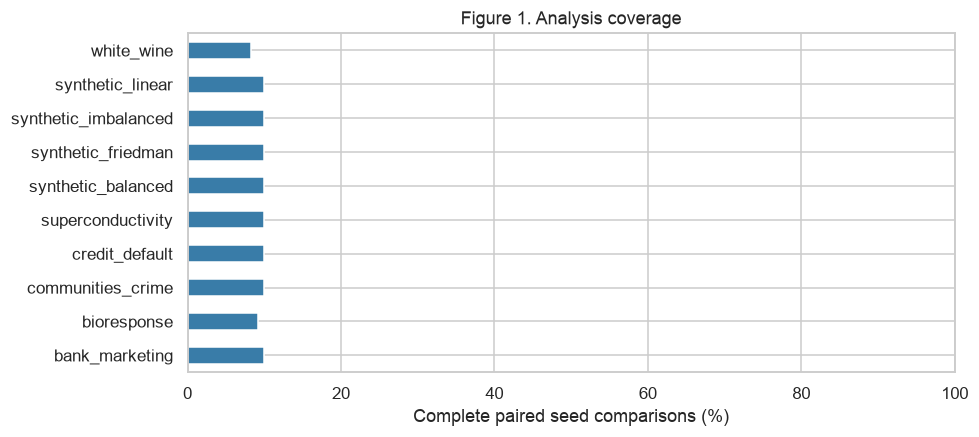

In [15]:
expected_cells = []
for dataset, spec in CONFIG['datasets'].items():
    for condition in spec['conditions']:
        for model in ['elastic_net', 'svm', 'lightgbm']:
            if model == 'svm' and not spec['small'] and condition != 'small':
                continue
            expected_cells.append((dataset, condition, model))
expected_set = set(expected_cells)
records, skipped = [], Counter()
for path in sorted((ROOT / 'results/runs').glob('*.json')):
    try:
        raw = json.loads(path.read_text())
    except (OSError, ValueError):
        skipped['unreadable snapshot'] += 1
        continue
    c = raw.get('config', {})
    if raw.get('status') != 'complete':
        skipped[raw.get('status', 'unknown')] += 1
        continue
    if c.get('budget') not in BUDGETS or c.get('seed') not in SEEDS or tuple(c.get(k) for k in CELL) not in expected_set or c.get('optimizer') not in OPTIMIZERS:
        skipped['pilot or outside manifest'] += 1
        continue
    space_spec = SPACES[c['model']]
    task = CONFIG['datasets'][c['dataset']]['task']
    expected_space = {f'model__{k}': v for k, v in {**space_spec.get('common', {}), **space_spec.get(task, {})}.items()}
    if c.get('space') != expected_space or c.get('dataset_spec') != CONFIG['datasets'][c['dataset']] or c.get('cv_folds') != CONFIG['cv_folds'] or c.get('n_jobs') != CONFIG.get('cv_jobs', CONFIG.get('n_jobs', 1)):
        skipped['incompatible protocol'] += 1
        continue
    records.append((path, raw))
cohorts = Counter(r['config'].get('source_hash', 'unknown') for _, r in records)
selected_hash = SOURCE_HASH or (cohorts.most_common(1)[0][0] if cohorts else None)
selected = [(p, r) for p, r in records if r['config'].get('source_hash', 'unknown') == selected_hash]
# Retain latest saved completed file when Git-only changes created duplicates.
unique = {}
for path, raw in selected:
    c = raw['config']
    key = tuple(c[k] for k in CELL + ['optimizer', 'budget', 'seed'])
    if key not in unique or path.stat().st_mtime_ns > unique[key][0].stat().st_mtime_ns:
        unique[key] = (path, raw)
selected = list(unique.values())
rows, histories = [], []
for path, raw in selected:
    c = raw['config']; task = CONFIG['datasets'][c['dataset']]['task']
    for s in raw.get('summaries', []):
        if s['budget'] in BUDGETS:
            rows.append({**{k: c[k] for k in CELL + ['optimizer', 'seed']}, **s, 'task': task,
                         'source_hash': selected_hash, 'run_id': raw['run_id']})
    for index, trial in enumerate(raw.get('trials', [])):
        histories.append({**{k: c[k] for k in CELL + ['optimizer', 'seed']}, **trial,
                          'run_budget': c['budget'], 'trial': index + 1, 'task': task})
columns = PAIR + ['optimizer', 'task', 'test_score', 'validation_score', 'optimization_seconds', 'generalization_gap', 'best_trial_converged', 'refit_converged']
results = pd.DataFrame(rows).reindex(columns=list(dict.fromkeys(columns + [k for r in rows for k in r])))
history = pd.DataFrame(histories)
if not results.empty:
    results['loss'] = np.where(results['task'].eq('regression'), results['test_score'], -results['test_score'])
    results['comparison_count'] = results.groupby(PAIR)['optimizer'].transform('nunique')
    paired = results[results['comparison_count'].eq(len(OPTIMIZERS))].copy()
else:
    results['loss'] = pd.Series(dtype=float)
    paired = results.copy()
coverage = pd.DataFrame([{'dataset': d, 'condition': c, 'model': m, 'budget': b,
    'complete_optimizer_seed_scores': len(results[(results.dataset == d) & (results.condition == c) & (results.model == m) & (results.budget == b)]),
    'paired_seeds': len(paired[(paired.dataset == d) & (paired.condition == c) & (paired.model == m) & (paired.budget == b)]) // len(OPTIMIZERS),
    'expected_seeds': len(SEEDS)} for d,c,m in expected_cells for b in BUDGETS])
print(f'Selected source: {selected_hash}; completed runs: {len(selected)}; paired seed/budget comparisons: {len(paired)//4}')
display(pd.DataFrame([{'source_hash': h, 'eligible_run_files': n, 'selected': h == selected_hash} for h,n in cohorts.items()]))
print('Excluded files:', dict(skipped))
export_table(coverage, 'table_01_coverage')
manifest = {'source_hash': selected_hash, 'seeds': SEEDS, 'files': [p.name for p,_ in selected],
            'file_sha256': {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p,_ in selected}, 'excluded': dict(skipped)}
(OUT / 'snapshot_manifest.json').write_text(json.dumps(manifest, indent=2))
fig, ax = plt.subplots(figsize=(9, 4))
snapshot_coverage = coverage.groupby('dataset')[['paired_seeds', 'expected_seeds']].sum()
snapshot_coverage['percent'] = 100 * snapshot_coverage.paired_seeds / snapshot_coverage.expected_seeds
snapshot_coverage['percent'].plot.barh(ax=ax, color='#397ca8')
ax.set(xlim=(0,100), xlabel='Complete paired seed comparisons (%)', ylabel='', title='Figure 1. Analysis coverage')
export_figure(fig, 'figure_01_coverage')

## 2. Predictive performance and optimizer ranks

Raw RMSE (lower is better) and ROC-AUC (higher is better) are reported **within each dataset**. We do not average raw metrics across datasets. The detailed table reports seed means and standard deviations from complete paired comparisons; with one seed, standard deviation is undefined.

For a compact cross-dataset comparison, rank optimizers from 1 (best) to 4 (worst), using average ranks for ties. Average seeds within a condition, then conditions within a dataset, then dataset blocks. The four synthetic generators form **one synthetic-family block**, preventing them from receiving four times the weight of a real dataset. Descriptive partial panels can still be unbalanced; coverage must accompany every claim.

,dataset,condition,model,task,budget,optimizer,mean_test_score,sd_test_score,seeds,mean_validation_score
0,bank_marketing,base,elastic_net,classification,25,bayesian,0.770105,NaN,1,0.766582
1,bank_marketing,base,elastic_net,classification,25,grid,0.769715,NaN,1,0.765775
2,bank_marketing,base,elastic_net,classification,25,halving,0.769878,NaN,1,0.766266
3,bank_marketing,base,elastic_net,classification,25,random,0.770625,NaN,1,0.766927
4,bank_marketing,base,elastic_net,classification,100,bayesian,0.770689,NaN,1,0.766934
...,...,...,...,...,...,...,...,...,...,...
391,white_wine,noisy,svm,regression,25,random,0.708780,NaN,1,0.829935
392,white_wine,noisy,svm,regression,100,bayesian,0.701578,NaN,1,0.819981
393,white_wine,noisy,svm,regression,100,grid,0.707395,NaN,1,0.826711
394,white_wine,noisy,svm,regression,100,halving,0.699165,NaN,1,0.822440


,model,budget,optimizer,mean_rank,blocks
0,elastic_net,25,bayesian,2.333333,7
1,elastic_net,25,grid,2.636905,7
2,elastic_net,25,halving,2.333333,7
3,elastic_net,25,random,2.696429,7
4,elastic_net,100,bayesian,2.357143,7
5,elastic_net,100,grid,2.440476,7
6,elastic_net,100,halving,2.720238,7
7,elastic_net,100,random,2.482143,7
8,lightgbm,25,bayesian,1.928571,7
9,lightgbm,25,grid,3.464286,7


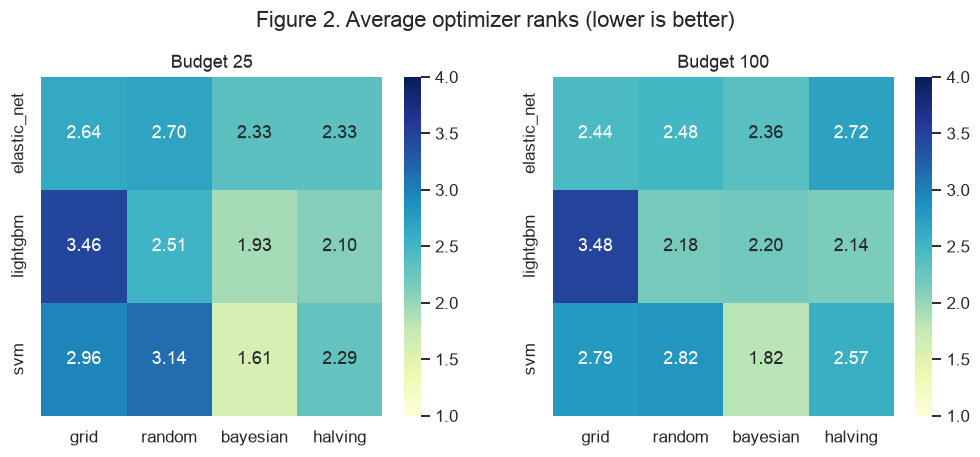

In [16]:
performance = paired.groupby(CELL + ['task', 'budget', 'optimizer']).agg(
    mean_test_score=('test_score','mean'), sd_test_score=('test_score','std'), seeds=('seed','nunique'),
    mean_validation_score=('validation_score','mean')).reset_index()
export_table(performance, 'table_02_performance')
if not paired.empty:
    paired['rank'] = paired.groupby(PAIR)['loss'].rank(method='average', ascending=True)
    paired['block'] = paired['dataset'].where(~paired['dataset'].str.startswith('synthetic_'), 'synthetic_family')
    condition_ranks = paired.groupby(CELL + ['block','budget','optimizer'])['rank'].mean().reset_index()
    dataset_ranks = condition_ranks.groupby(['dataset','block','model','budget','optimizer'])['rank'].mean().reset_index()
    block_ranks = dataset_ranks.groupby(['block','model','budget','optimizer'])['rank'].mean().reset_index()
    rank_summary = block_ranks.groupby(['model','budget','optimizer']).agg(mean_rank=('rank','mean'), blocks=('block','nunique')).reset_index()
    export_table(rank_summary, 'table_03_average_ranks')
    fig, axes = plt.subplots(1, len(BUDGETS), figsize=(11,4), squeeze=False)
    for ax, budget in zip(axes.flat, BUDGETS):
        table = rank_summary[rank_summary.budget.eq(budget)].pivot(index='model', columns='optimizer', values='mean_rank').reindex(columns=OPTIMIZERS)
        if table.empty: ax.text(.5,.5,'No paired results',ha='center'); ax.axis('off'); continue
        sns.heatmap(table, annot=True, fmt='.2f', vmin=1, vmax=4, cmap='YlGnBu', ax=ax)
        ax.set(title=f'Budget {budget}', xlabel='', ylabel='')
    fig.suptitle('Figure 2. Average optimizer ranks (lower is better)', y=1.03)
    export_figure(fig, 'figure_02_rank_heatmap')
else:
    print('Performance comparisons deferred: no complete optimizer pairs.')

## 3. Effect of increasing the budget

Match budget 25 and 100 for the **same seed, model, dataset, condition, and optimizer**. Positive gain means improved test performance: RMSE(25) − RMSE(100) for regression; AUC(100) − AUC(25) for classification. Keep task scales separate. More search can improve validation performance without improving held-out performance; report negative gains too. These observations describe variability and are not independent samples for a pooled significance test.

,task,model,optimizer,mean_gain,median_gain,paired_observations
0,classification,elastic_net,bayesian,0.000220,4.509874e-05,9
1,classification,elastic_net,grid,0.000224,5.708691e-04,9
2,classification,elastic_net,halving,0.000121,0.000000e+00,9
3,classification,elastic_net,random,0.000868,8.063123e-07,9
4,classification,lightgbm,bayesian,-0.000398,-5.035017e-04,10
5,classification,lightgbm,grid,0.003417,1.448364e-03,10
6,classification,lightgbm,halving,0.004160,1.662736e-03,10
7,classification,lightgbm,random,0.000507,9.995278e-04,10
8,classification,svm,bayesian,0.003462,3.607929e-03,6
9,classification,svm,grid,0.018370,5.508341e-03,6


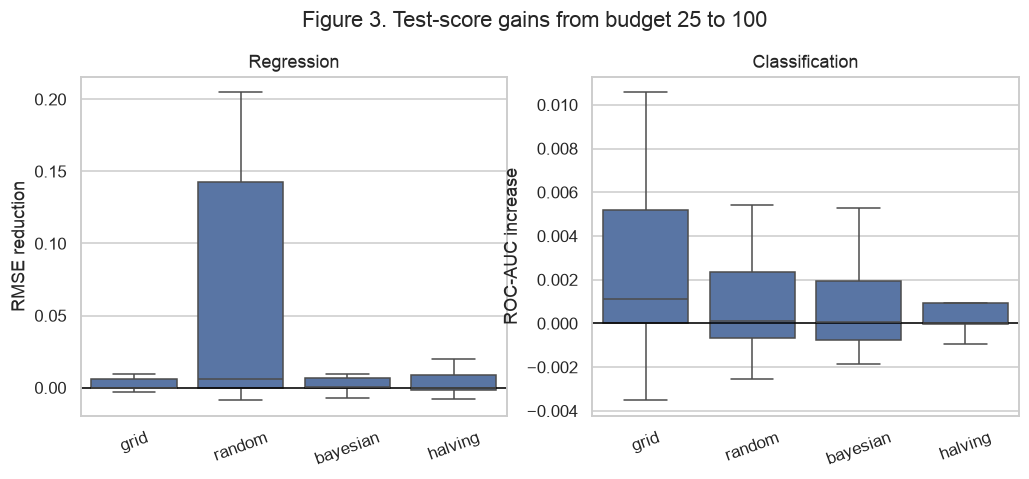

In [17]:
if not paired.empty and 25 in BUDGETS and 100 in BUDGETS:
    gains = paired.pivot(index=CELL + ['task','optimizer','seed'], columns='budget', values='loss').dropna(subset=[25,100])
    gains['test_gain'] = gains[25] - gains[100]
    gains = gains.reset_index()
    gain_table = gains.groupby(['task','model','optimizer']).agg(mean_gain=('test_gain','mean'), median_gain=('test_gain','median'), paired_observations=('seed','size')).reset_index()
    export_table(gain_table, 'table_04_budget_gain')
    fig, axes = plt.subplots(1,2,figsize=(11,4))
    for ax, task in zip(axes,['regression','classification']):
        subset = gains[gains.task.eq(task)]
        if subset.empty: ax.text(.5,.5,'No matched budgets',ha='center'); ax.axis('off'); continue
        sns.boxplot(data=subset,x='optimizer',y='test_gain',order=OPTIMIZERS,ax=ax,showfliers=False)
        ax.axhline(0,color='black',lw=1)
        ax.set(title=task.title(),xlabel='',ylabel='RMSE reduction' if task=='regression' else 'ROC-AUC increase')
        ax.tick_params(axis='x',rotation=20)
    fig.suptitle('Figure 3. Test-score gains from budget 25 to 100',y=1.03)
    export_figure(fig,'figure_03_budget_gain')

## 4. Runtime and seed consistency

Optimization time excludes downloading, preprocessing outside CV, and final refits. For random/Bayesian budget 25, time is the elapsed time through trial 25 of the longer run. Hardware load and simultaneous batches can affect timings; elapsed times alone do not establish intrinsic algorithm complexity.

Compare time ratios against random search within matched comparisons, then report the median ratio. The variability table reports standard deviation across seeds within each cell; it does not conflate between-dataset differences with seed variability.

,model,budget,optimizer,median_minutes,total_recorded_hours,observations
0,elastic_net,25,bayesian,0.132929,1.216180,19
1,elastic_net,25,grid,0.097293,1.333868,19
2,elastic_net,25,halving,0.289136,1.056307,19
3,elastic_net,25,random,0.069695,1.494312,19
4,elastic_net,100,bayesian,0.447582,2.055910,18
5,elastic_net,100,grid,0.377666,3.579574,18
6,elastic_net,100,halving,1.222953,3.016717,18
7,elastic_net,100,random,0.324857,3.399977,18
8,lightgbm,25,bayesian,0.142454,0.096050,19
9,lightgbm,25,grid,0.119840,0.052199,19


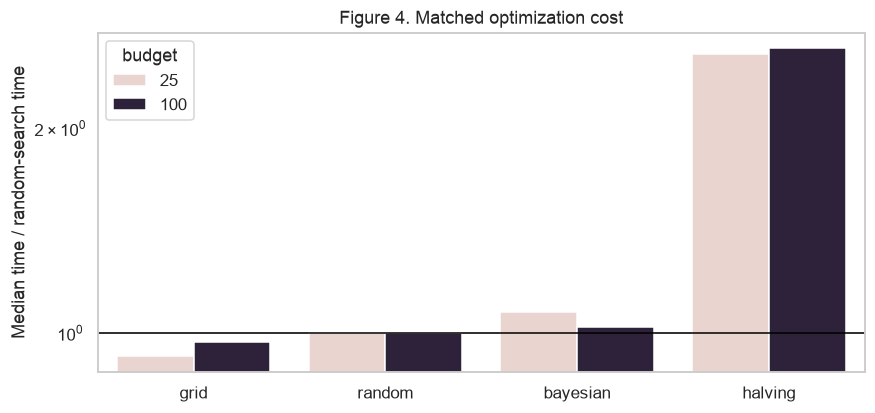

,dataset,condition,model,task,budget,optimizer,seed_sd,seed_count
0,bank_marketing,base,elastic_net,classification,25,bayesian,NaN,1
1,bank_marketing,base,elastic_net,classification,25,grid,NaN,1
2,bank_marketing,base,elastic_net,classification,25,halving,NaN,1
3,bank_marketing,base,elastic_net,classification,25,random,NaN,1
4,bank_marketing,base,elastic_net,classification,100,bayesian,NaN,1
...,...,...,...,...,...,...,...,...
391,white_wine,noisy,svm,regression,25,random,NaN,1
392,white_wine,noisy,svm,regression,100,bayesian,NaN,1
393,white_wine,noisy,svm,regression,100,grid,NaN,1
394,white_wine,noisy,svm,regression,100,halving,NaN,1


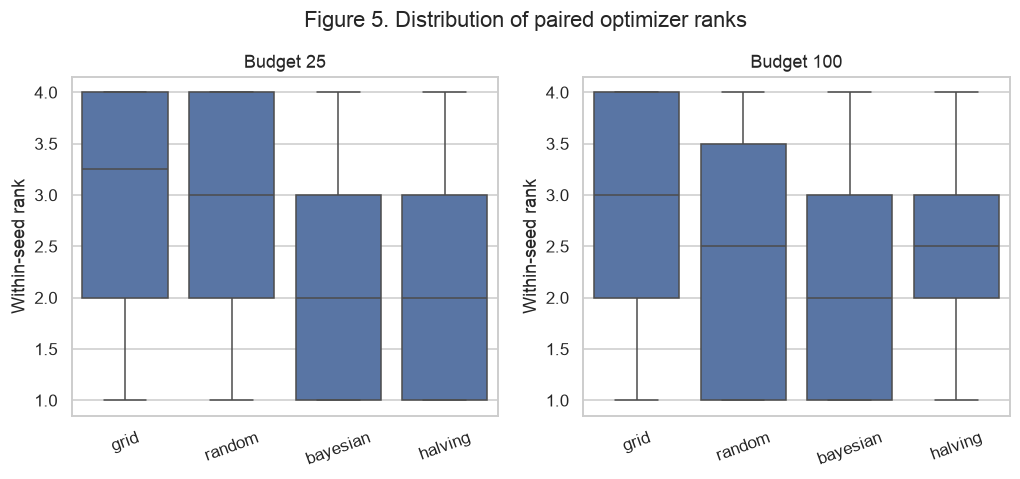

In [18]:
if not paired.empty:
    time_table = paired.groupby(['model','budget','optimizer']).agg(median_minutes=('optimization_seconds',lambda x: x.median()/60), total_recorded_hours=('optimization_seconds',lambda x: x.sum()/3600), observations=('seed','size')).reset_index()
    export_table(time_table,'table_05_runtime')
    times = paired.pivot(index=PAIR,columns='optimizer',values='optimization_seconds')
    ratios = times.div(times['random'].replace(0,np.nan),axis=0).reset_index().melt(id_vars=PAIR,var_name='optimizer',value_name='time_ratio')
    fig, ax = plt.subplots(figsize=(9,4))
    sns.barplot(data=ratios,x='optimizer',y='time_ratio',hue='budget',order=OPTIMIZERS,estimator=np.median,errorbar=None,ax=ax)
    ax.axhline(1,color='black',lw=1)
    ax.set(yscale='log',xlabel='',ylabel='Median time / random-search time',title='Figure 4. Matched optimization cost')
    export_figure(fig,'figure_04_runtime_ratio')
    stability = paired.groupby(CELL + ['task','budget','optimizer']).agg(seed_sd=('test_score','std'),seed_count=('seed','nunique')).reset_index()
    export_table(stability,'table_06_seed_variability')
    fig, axes = plt.subplots(1,len(BUDGETS),figsize=(11,4),squeeze=False)
    for ax,budget in zip(axes.flat,BUDGETS):
        sub=paired[paired.budget.eq(budget)]
        if sub.empty: ax.axis('off');continue
        sns.boxplot(data=sub,x='optimizer',y='rank',order=OPTIMIZERS,ax=ax,showfliers=False)
        ax.set(title=f'Budget {budget}',xlabel='',ylabel='Within-seed rank');ax.tick_params(axis='x',rotation=20)
    fig.suptitle('Figure 5. Distribution of paired optimizer ranks',y=1.03)
    export_figure(fig,'figure_05_rank_variability')

## 5. Search trajectories: a representative example

These curves show **validation scores**, not repeated test-set evaluations. The test set is used only after selection. For halving, low-resource scores are not directly comparable with full-resource scores; only full-resource trials enter the best-so-far envelope. Their cumulative resource and time still include earlier rungs. Training-resource equivalents are an approximate cost measure, not a guarantee of equal CPU work.

Choose an example by a fixed rule (the first alphabetically available complete high-budget comparison), rather than selecting the most favorable result. Set `EXAMPLE` to a documented dataset/condition/model/seed tuple if a particular case is scientifically motivated.

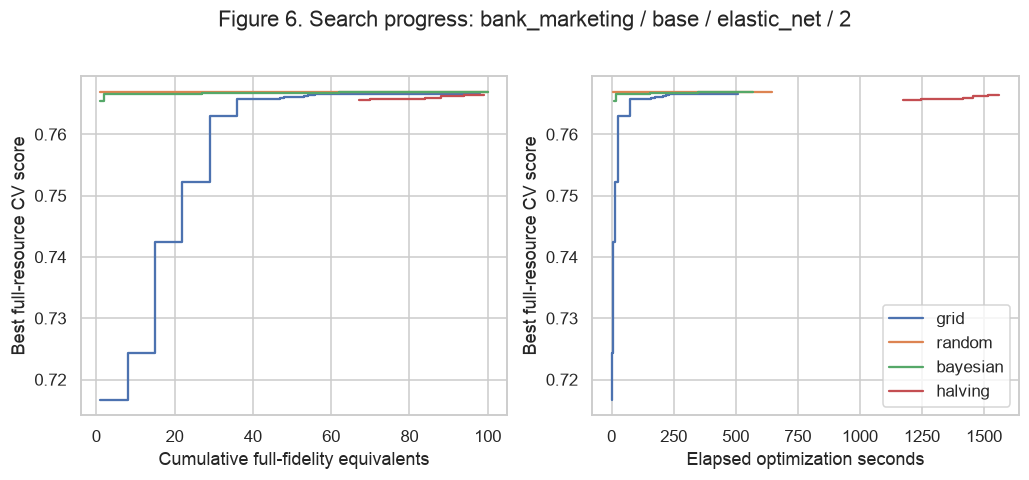

In [19]:
EXAMPLE = None  # e.g. ('white_wine', 'base', 'elastic_net', 1)
if not paired.empty and not history.empty:
    available = paired[paired.budget.eq(max(BUDGETS))][CELL+['seed']].drop_duplicates().sort_values(CELL+['seed'])
    example = EXAMPLE or (tuple(available.iloc[0]) if not available.empty else None)
    if example:
        subset=history.copy()
        for key,value in zip(CELL+['seed'],example): subset=subset[subset[key].eq(value)]
        subset=subset[subset.run_budget.eq(max(BUDGETS))]
        fig,axes=plt.subplots(1,2,figsize=(11,4))
        for optimizer in OPTIMIZERS:
            curve=subset[subset.optimizer.eq(optimizer)].sort_values('trial').copy()
            if curve.empty:continue
            curve['equivalents']=curve.resource.cumsum()
            curve['best']=curve.score.where(curve.resource.eq(1)).cummax().ffill()
            if curve.task.iloc[0]=='regression':curve['best']=-curve['best']
            for ax,x in zip(axes,['equivalents','elapsed_seconds']):
                ax.step(curve[x],curve['best'],where='post',label=optimizer)
        axes[0].set(xlabel='Cumulative full-fidelity equivalents',ylabel='Best full-resource CV score')
        axes[1].set(xlabel='Elapsed optimization seconds',ylabel='Best full-resource CV score')
        axes[1].legend()
        fig.suptitle('Figure 6. Search progress: '+ ' / '.join(map(str,example)),y=1.03)
        export_figure(fig,'figure_06_convergence_example')

## 6. Statistical comparison across dataset blocks

**Unit of analysis:** a dataset block, not a seed or a dataset–condition–model cell. For each model and budget, average seed ranks within conditions, average conditions within a dataset, and average the four synthetic generators into one synthetic-family block. This reduces pseudoreplication, although datasets are a selected benchmark sample rather than a random population sample.

**Primary test:** Friedman test of equal optimizer rank distributions across blocks. We defer testing until every planned cell and seed for that model/budget is available, with at least five blocks and all selected best trials/refits known to have converged. Ties use average ranks; if every optimizer ties on every block, p=1.

Apply **Holm correction across the six planned model × budget Friedman tests** (using p=1 for deferred tests preserves the planned family size). If the corrected omnibus test is significant, perform Nemenyi all-pairs comparisons using the studentized-range distribution. Its critical difference is a conventional within-panel 5% threshold, not a global threshold across all panels. The numerical pairwise table is preferable to declaring significance from visual rank spacing. This replaces a complex critical-difference diagram with an easily presented average-rank plot and a complete pairwise appendix table.

This is a small-block, approximate nonparametric analysis; lack of significance does not establish equivalence. No formal significance claims should be made from an unfinished batch or from repeated interim inspection.

Method references: [Demšar (2006)](https://www.jmlr.org/papers/v7/demsar06a.html), [SciPy Friedman documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.friedmanchisquare.html), and [studentized-range distribution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.studentized_range.html). With only 4–7 dataset blocks, asymptotic Friedman p-values can be inaccurate; treat them as exploratory supporting evidence, not definitive confirmation.


In [20]:
def holm_adjust(pvalues):
    p=np.asarray(pvalues,float); order=np.argsort(p)
    adjusted=np.empty(len(p)); adjusted[order]=np.minimum(1,np.maximum.accumulate(p[order]*(len(p)-np.arange(len(p)))))
    return adjusted
omnibus=[]; panel_matrices={}
for model in ['elastic_net','svm','lightgbm']:
    for budget in BUDGETS:
        expected=[cell for cell in expected_cells if cell[2]==model]
        sub=paired[(paired.model==model)&(paired.budget==budget)]
        full=len(sub)==len(expected)*len(SEEDS)*len(OPTIMIZERS)
        diagnostics_known = not sub.empty and sub[['best_trial_converged','refit_converged']].notna().all().all()
        converged=diagnostics_known and sub[['best_trial_converged','refit_converged']].eq(True).all().all()
        reason='ready' if full and converged else ('incomplete panel' if not full else 'missing or failed convergence diagnostics')
        matrix=None; stat=np.nan;p=1.;cd=np.nan;n=0
        if full and converged:
            matrix=block_ranks[(block_ranks.model==model)&(block_ranks.budget==budget)].pivot(index='block',columns='optimizer',values='rank').reindex(columns=OPTIMIZERS).dropna()
            # Re-rank aggregated block scores so Friedman and Nemenyi use the same ranks.
            matrix=matrix.rank(axis=1, method='average', ascending=True)
            n=len(matrix)
            if n<5:reason='fewer than five blocks'
            else:
                if np.allclose(matrix.to_numpy(),matrix.to_numpy()[:,[0]]):stat,p=0.,1.
                else:stat,p=friedmanchisquare(*[matrix[o].to_numpy() for o in OPTIMIZERS])
                cd=studentized_range.ppf(.95,len(OPTIMIZERS),np.inf)/np.sqrt(2)*np.sqrt(len(OPTIMIZERS)*(len(OPTIMIZERS)+1)/(6*n))
                panel_matrices[(model,budget)]=matrix
        omnibus.append(dict(model=model,budget=budget,status=reason,blocks=n,friedman_statistic=stat,p_value=p if reason=='ready' else np.nan,planned_family_p=p,critical_difference_05=cd))
stats=pd.DataFrame(omnibus)
stats['holm_p']=holm_adjust(stats.planned_family_p)
stats.loc[stats.status.ne('ready'),'holm_p']=np.nan
stats['reject_equal_ranks']=stats.holm_p.lt(.05)
export_table(stats.drop(columns='planned_family_p'),'table_07_friedman')
pairwise=[]
for row in stats.itertuples():
    if row.status!='ready' or not row.reject_equal_ranks:continue
    matrix=panel_matrices[(row.model,row.budget)];means=matrix.mean();k=len(OPTIMIZERS);n=len(matrix)
    se=np.sqrt(k*(k+1)/(6*n))
    for a,b in itertools.combinations(OPTIMIZERS,2):
        difference=means[a]-means[b]
        p=float(studentized_range.sf(abs(difference)/se*np.sqrt(2),k,np.inf))
        pairwise.append(dict(model=row.model,budget=row.budget,optimizer_a=a,optimizer_b=b,mean_rank_difference_a_minus_b=difference,nemenyi_p=p,reject_within_panel=p<.05))
export_table(pd.DataFrame(pairwise,columns=['model','budget','optimizer_a','optimizer_b','mean_rank_difference_a_minus_b','nemenyi_p','reject_within_panel']),'table_08_nemenyi')

,model,budget,status,blocks,friedman_statistic,p_value,critical_difference_05,holm_p,reject_equal_ranks
0,elastic_net,25,incomplete panel,0,NaN,NaN,NaN,NaN,False
1,elastic_net,100,incomplete panel,0,NaN,NaN,NaN,NaN,False
2,svm,25,incomplete panel,0,NaN,NaN,NaN,NaN,False
3,svm,100,incomplete panel,0,NaN,NaN,NaN,NaN,False
4,lightgbm,25,incomplete panel,0,NaN,NaN,NaN,NaN,False
5,lightgbm,100,incomplete panel,0,NaN,NaN,NaN,NaN,False


,model,budget,optimizer_a,optimizer_b,mean_rank_difference_a_minus_b,nemenyi_p,reject_within_panel


## 7. Diagnostics, limitations, and report conclusions

A positive generalization gap means worse held-out performance: test RMSE − validation RMSE, or validation AUC − test AUC. Different validation/training conditions (especially added noise) also affect this difference, so it is not a pure measure of overfitting. Convergence flags describe solver warnings, not proof of reaching a global optimum. Missing diagnostics in older files remain unknown.

**Report caveats:** native LightGBM categorical handling and grid priorities must match the final stated protocol; halving uses approximate resource accounting and different candidate fidelity; observed optimizer ranks are specific to the chosen spaces and datasets. Models differ in more than search-space dimension, so this experiment cannot attribute every difference to dimensionality alone. Hardware contention can confound timing. Synthetic settings are related, and real datasets are a small selected sample.

**Final-report checklist:** freeze one protocol/cohort, finish planned paired comparisons, inspect convergence diagnostics, rerun this notebook once for the final snapshot, then base conclusions on practical score differences and time savings alongside corrected tests. Keep exploratory partial-result slides labeled provisional.

In [21]:
diagnostics=[]
for column in ['best_trial_converged','refit_converged']:
    values=results[column]
    diagnostics.append(dict(check=column,passed=int(values.eq(True).sum()),failed=int(values.eq(False).sum()),unknown=int(values.isna().sum())))
export_table(pd.DataFrame(diagnostics),'table_09_convergence_diagnostics')
gaps=paired.groupby(CELL+['task','budget','optimizer']).agg(mean_gap=('generalization_gap','mean'),sd_gap=('generalization_gap','std')).reset_index()
export_table(gaps,'table_10_generalization_gap')
if not paired.empty:
    winners=paired[paired['rank'].eq(paired.groupby(PAIR)['rank'].transform('min'))].copy()
    # Split win credit equally for ties.
    winners['win_credit']=1/winners.groupby(PAIR)['optimizer'].transform('size')
    wins=winners.groupby(['model','budget','optimizer']).agg(win_credit=('win_credit','sum')).reset_index()
    export_table(wins,'table_11_win_counts')
notes=f"""Analysis source: {selected_hash}
Completed files in snapshot: {len(selected)}
Complete paired comparisons: {len(paired)//4}
Formal tests ready: {int(stats.status.eq('ready').sum())} / {len(stats)}
Do not pool raw metrics across datasets or treat seeds as independent datasets.
Do not infer equal performance from a nonsignificant result.
Inspect tables 01 and 09 before reporting conclusions.
"""
(OUT/'report_notes.txt').write_text(notes)
print(notes)
display(Markdown('**Writing prompts:** Describe the leading optimizer by model and budget; quantify its raw-score advantage on representative datasets; state whether the gain justifies the measured time; distinguish stable patterns from uncertain comparisons. Avoid declaring a universal winner from partial coverage.'))

,check,passed,failed,unknown
0,best_trial_converged,388,12,0
1,refit_converged,391,9,0


,dataset,condition,model,task,budget,optimizer,mean_gap,sd_gap
0,bank_marketing,base,elastic_net,classification,25,bayesian,-0.003524,NaN
1,bank_marketing,base,elastic_net,classification,25,grid,-0.003940,NaN
2,bank_marketing,base,elastic_net,classification,25,halving,-0.003612,NaN
3,bank_marketing,base,elastic_net,classification,25,random,-0.003698,NaN
4,bank_marketing,base,elastic_net,classification,100,bayesian,-0.003755,NaN
...,...,...,...,...,...,...,...,...
391,white_wine,noisy,svm,regression,25,random,-0.121155,NaN
392,white_wine,noisy,svm,regression,100,bayesian,-0.118403,NaN
393,white_wine,noisy,svm,regression,100,grid,-0.119316,NaN
394,white_wine,noisy,svm,regression,100,halving,-0.123275,NaN


,model,budget,optimizer,win_credit
0,elastic_net,25,bayesian,3.0
1,elastic_net,25,grid,4.0
2,elastic_net,25,halving,7.0
3,elastic_net,25,random,5.0
4,elastic_net,100,bayesian,5.0
5,elastic_net,100,grid,5.0
6,elastic_net,100,halving,2.0
7,elastic_net,100,random,6.0
8,lightgbm,25,bayesian,8.0
9,lightgbm,25,halving,6.0


Analysis source: 5f5b6e60da15ed1c5be07110bdfa0c1147b0502ee46a819fca83e9e5d938fdb4
Completed files in snapshot: 300
Complete paired comparisons: 99
Formal tests ready: 0 / 6
Do not pool raw metrics across datasets or treat seeds as independent datasets.
Do not infer equal performance from a nonsignificant result.
Inspect tables 01 and 09 before reporting conclusions.



**Writing prompts:** Describe the leading optimizer by model and budget; quantify its raw-score advantage on representative datasets; state whether the gain justifies the measured time; distinguish stable patterns from uncertain comparisons. Avoid declaring a universal winner from partial coverage.